1. Laden der Trainingsdaten

In [1]:
import pandas as pd

df_train = pd.read_csv("data/project/train.csv" , sep=";")
df_train.head()

,transactionId,basket,customerType,totalAmount,returnLabel
0,9534310106,"[4, 3, 4]",new,252.0,1
1,7202594767,"[4, 2, 0, 2, 5]",existing,70.0,0
2,2737331698,[5],existing,84.0,0
3,4868011733,"[1, 4, 2, 4]",existing,116.0,0
4,7622406570,"[2, 5, 3, 2, 3, 2, 0]",existing,378.0,0


2. Explorative Datenanalyse (EDA)

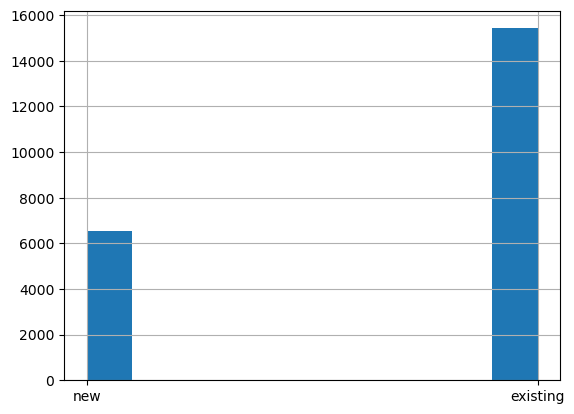

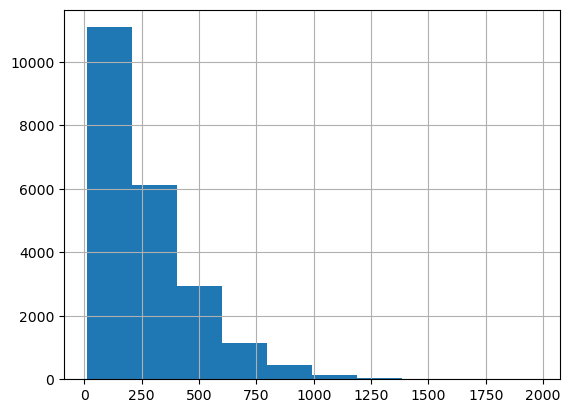

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

df_train["customerType"].hist()
plt.show()

df_train["totalAmount"].hist()
plt.show()

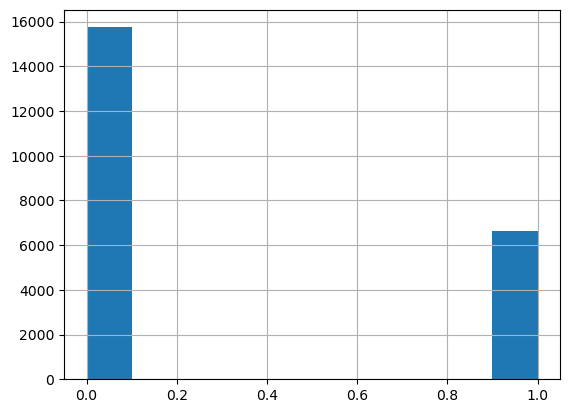

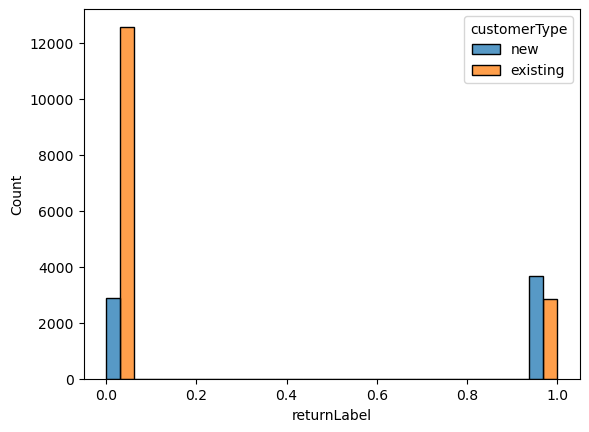

In [3]:

df_train["returnLabel"].hist()
plt.show()


sns.histplot(data=df_train, x="returnLabel", hue="customerType", multiple="dodge", )
plt.show()

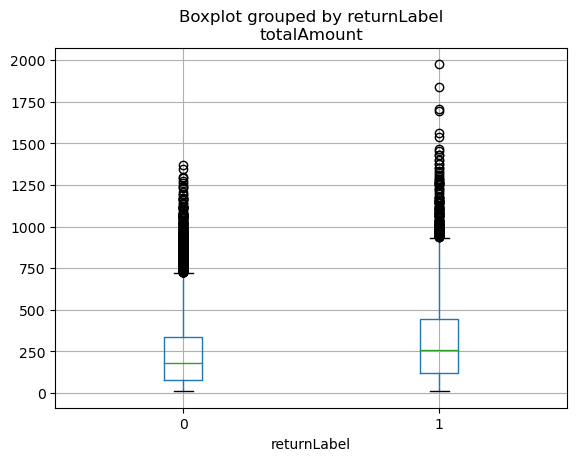

In [4]:
df_train.boxplot(column="totalAmount", by="returnLabel")
plt.show()

/home/alex/miniconda3/envs/ml-course/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


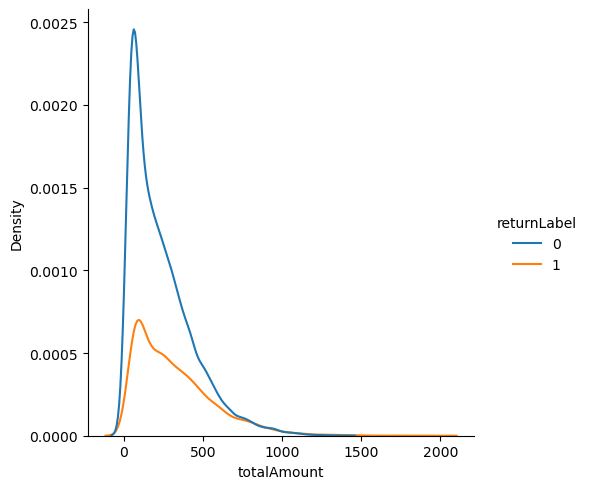

In [5]:
sns.displot(data=df_train, x="totalAmount", hue="returnLabel", kind="kde")
plt.show()

3. Auffüllen der Fehlenden Werte

In [6]:
df_train.isna().sum()

transactionId      0
basket             0
customerType     442
totalAmount      477
returnLabel        0
dtype: int64

In [7]:
mode_customer = df_train["customerType"].mode()[0]
df_train["customerType"] = df_train["customerType"].fillna(mode_customer)

median_amount = df_train["totalAmount"].median()
df_train["totalAmount"] = df_train["totalAmount"].fillna(median_amount)

df_train.isna().sum()

transactionId    0
basket           0
customerType     0
totalAmount      0
returnLabel      0
dtype: int64

4. und 5. Feature-Transformation und Basket-Features

In [8]:
import ast

def transform_features(df):
    df_copy = df.copy()
    
    df_copy["basket"] = df_copy["basket"].apply(ast.literal_eval)
    
    for i in range(6):
        df_copy[f"basket_count_{i}"] = df_copy["basket"].apply(lambda x: x.count(i))
        
    df_copy = pd.get_dummies(df_copy, columns=["customerType"], drop_first=False)
    
    df_copy = df_copy.drop(columns=["transactionId", "basket"], errors="ignore")
    
    return df_copy

df_train_transformed = transform_features(df_train)
df_train_transformed.head()

,totalAmount,returnLabel,basket_count_0,basket_count_1,basket_count_2,basket_count_3,basket_count_4,basket_count_5,customerType_existing,customerType_new
0,252.0,1,0,0,0,1,2,0,False,True
1,70.0,0,1,0,2,0,1,1,True,False
2,84.0,0,0,0,0,0,0,1,True,False
3,116.0,0,0,1,1,0,2,0,True,False
4,378.0,0,1,0,3,2,0,1,True,False


6. Features mit dem Standardscaler skalieren

In [9]:
from sklearn.preprocessing import StandardScaler

X_train = df_train_transformed.drop(columns=["returnLabel"])
y_train = df_train_transformed["returnLabel"]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

7. Training der Klassifikationsmodelle mit Cross-Validation

In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

param_grid_lr = {
    "C": [0.1, 1, 4, 5, 6, 10, 30, 100],
    "penalty": ["l1", "l2"]
}

grid_lr = GridSearchCV(
    estimator=LogisticRegression(solver="liblinear", random_state=42),
    param_grid=param_grid_lr,
    cv=5,
    scoring="accuracy"
)
grid_lr.fit(X_train_scaled, y_train)

param_grid_rf = {
    "n_estimators": [60, 80, 100, 120, 140],
    "max_depth": [2, 4, 6]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=5,
    scoring="accuracy"
)
grid_rf.fit(X_train_scaled, y_train)

grid_gb = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=5,
    scoring="accuracy"
)
grid_gb.fit(X_train_scaled, y_train)

print(grid_lr.best_params_)
print(grid_rf.best_params_)
print(grid_gb.best_params_)

{'C': 100, 'penalty': 'l2'}
{'max_depth': 6, 'n_estimators': 80}
{'max_depth': 4, 'n_estimators': 100}


8 + 9 + 10 +11. Laden der Testdaten

In [11]:
df_test = pd.read_csv("data/project/test.csv", sep=";")


df_test = df_test.dropna(subset=["customerType", "totalAmount"])


X_test = transform_features(df_test)


X_test_features = X_test.drop(columns=["returnLabel"], errors="ignore")
y_test = X_test["returnLabel"]


X_test_scaled = scaler.transform(X_test_features)

12. Vorhersage auf den Testdaten mit den besten Hyperparametern

In [12]:
y_pred_lr = grid_lr.predict(X_test_scaled)
y_pred_rf = grid_rf.predict(X_test_scaled)
y_pred_gb = grid_gb.predict(X_test_scaled)

13. Berechnung von Accuracy, Precision und Recall für alle drei Modelle

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

metrics_data = {
    "Modell": ["Logistische Regression", "Random Forest", "Gradient Boosting"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb)
    ]
}

df_metrics = pd.DataFrame(metrics_data)
df_metrics

,Modell,Accuracy,Precision,Recall
0,Logistische Regression,0.872859,0.815317,0.742193
1,Random Forest,0.860828,0.799511,0.712418
2,Gradient Boosting,0.871342,0.798704,0.760712


14. Vergleich der Accuracy -> Trainings und Testdaten (Overfitting > 5%?)

In [14]:

y_train_pred_lr = grid_lr.predict(X_train_scaled)
y_train_pred_rf = grid_rf.predict(X_train_scaled)
y_train_pred_gb = grid_gb.predict(X_train_scaled)


train_acc_lr = accuracy_score(y_train, y_train_pred_lr)
train_acc_rf = accuracy_score(y_train, y_train_pred_rf)
train_acc_gb = accuracy_score(y_train, y_train_pred_gb)


test_acc_lr = accuracy_score(y_test, y_pred_lr)
test_acc_rf = accuracy_score(y_test, y_pred_rf)
test_acc_gb = accuracy_score(y_test, y_pred_gb)


overfitting_data = {
    "Modell": ["Logistische Regression", "Random Forest", "Gradient Boosting"],
    "Trainings-Accuracy": [train_acc_lr, train_acc_rf, train_acc_gb],
    "Test-Accuracy": [test_acc_lr, test_acc_rf, test_acc_gb],
    "Unterschied (Train - Test)": [
        train_acc_lr - test_acc_lr,
        train_acc_rf - test_acc_rf,
        train_acc_gb - test_acc_gb
    ]
}

df_overfitting = pd.DataFrame(overfitting_data)
df_overfitting

,Modell,Trainings-Accuracy,Test-Accuracy,Unterschied (Train - Test)
0,Logistische Regression,0.878437,0.872859,0.005578
1,Random Forest,0.871161,0.860828,0.010333
2,Gradient Boosting,0.884866,0.871342,0.013524


15. Bestimmung der von allen drei Modellen falsch klassifizierten Datenpunkte

In [15]:
import numpy as np


falsch_lr = np.where(y_test != y_pred_lr)[0]
falsch_rf = np.where(y_test != y_pred_rf)[0]
falsch_gb = np.where(y_test != y_pred_gb)[0]


set_lr = set(falsch_lr)
set_rf = set(falsch_rf)
set_gb = set(falsch_gb)


gemeinsame_fehler = set_lr.intersection(set_rf).intersection(set_gb)


print("Falsch klassifiziert von LR:", len(set_lr))
print("Falsch klassifiziert von RF:", len(set_rf))
print("Falsch klassifiziert von GB:", len(set_gb))
print("-" * 40)
print("Anzahl der Datenpunkte, die von ALLEN DREI Modellen falsch klassifiziert wurden:", len(gemeinsame_fehler))

Falsch klassifiziert von LR: 1173
Falsch klassifiziert von RF: 1284
Falsch klassifiziert von GB: 1187
----------------------------------------
Anzahl der Datenpunkte, die von ALLEN DREI Modellen falsch klassifiziert wurden: 908


16. Vergleich der Feature-Importances aller drei Modelle

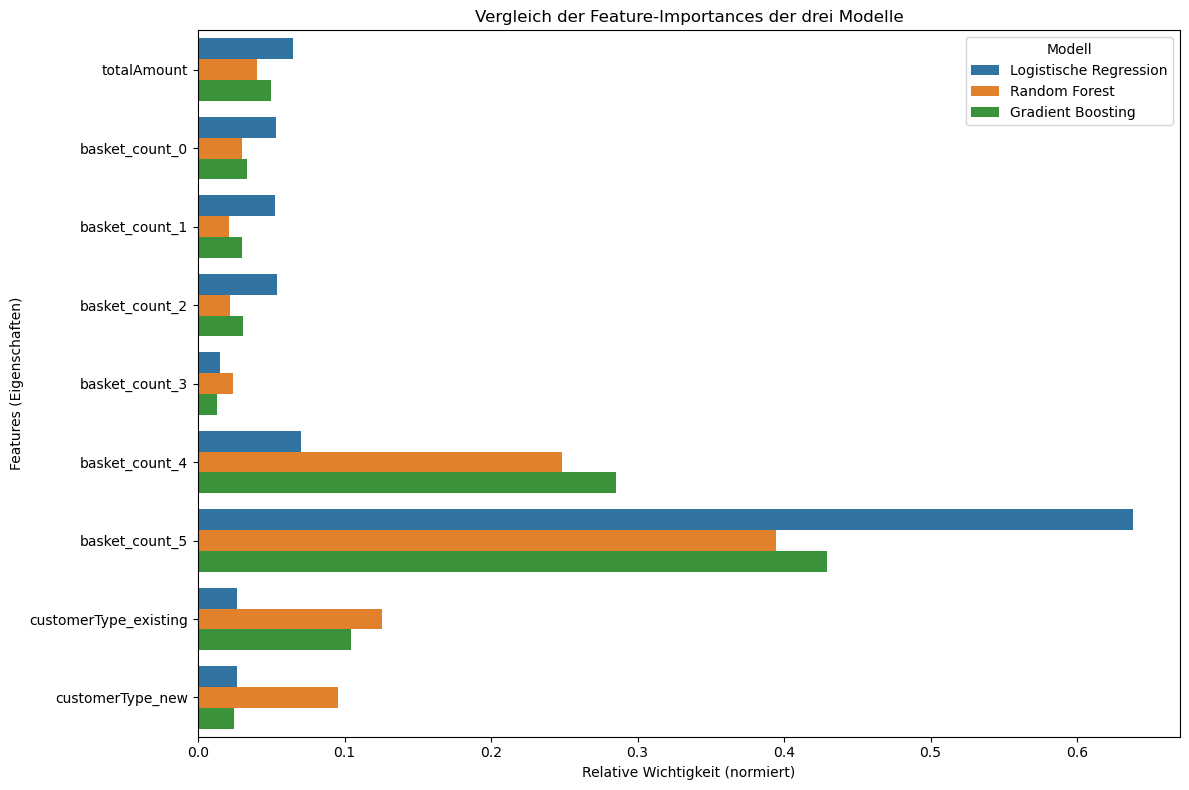

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns


feature_names = X_test_features.columns


lr_coefs = np.abs(grid_lr.best_estimator_.coef_[0])
lr_importances = lr_coefs / np.sum(lr_coefs)

rf_importances = grid_rf.best_estimator_.feature_importances_
gb_importances = grid_gb.best_estimator_.feature_importances_


df_importance = pd.DataFrame({
    "Feature": feature_names,
    "Logistische Regression": lr_importances,
    "Random Forest": rf_importances,
    "Gradient Boosting": gb_importances
})


df_importance_melted = df_importance.melt(id_vars="Feature", var_name="Modell", value_name="Wichtigkeit")


plt.figure(figsize=(12, 8))
sns.barplot(data=df_importance_melted, y="Feature", x="Wichtigkeit", hue="Modell")
plt.title("Vergleich der Feature-Importances der drei Modelle")
plt.xlabel("Relative Wichtigkeit (normiert)")
plt.ylabel("Features (Eigenschaften)")
plt.tight_layout()
plt.show()